In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

In [164]:
# base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir={'tpp': f"{root}/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525",
              'fragpipe':f"{root}/oui-discovery-vv-data/processed/msfragger_pride_reanalysis/fragpipe23_ms42",
                'ionbot-closed':f'{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results',
            'ionbot-open':f'{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results',}

PXDs = [
    'PXD002057',
    'PXD005833',
    'PXD014258',
]

SEARCHES = [
    'canon',
    'trembl',
    'openprot',
]

In [167]:
def get_peptide_files(processed_dir, flag, SEARCHES, PXDs):
    folders = {search:{dataset_name:[] for dataset_name in PXDs} for search in SEARCHES}
    for dataset_name in PXDs:
        for search in SEARCHES:   
            if flag == 'tpp' :
                path = os.path.join(processed_dir, dataset_name, f'{dataset_name}-{search}')
                flds = os.listdir(path)
                for fld in flds:
                    fld = os.path.join(path, fld)
                    if "_pep.csv" in fld and "groupwalk_output_" in fld and not "_Occam" in fld and not "ipynb_checkpoints" in fld:
                        folders[search][dataset_name].append(fld)
            elif flag == 'fragpipe':
                path = os.path.join(processed_dir, search, dataset_name)
                flds = os.listdir(path)
                for fld in flds:
                    fld = os.path.join(path, fld)
                    for subfld in glob.glob(f"{fld}/*.csv"):
                        if "_pep.csv" in subfld and "groupwalk_output_" in subfld and not "_Occam" in subfld:
                            folders[search][dataset_name].append(subfld)
            elif flag == 'ionbot-closed':
                path = os.path.join(processed_dir, f'{dataset_name}-closed',f'{dataset_name}-closed-{search}')
                flds = os.listdir(path)
                for fld in flds:
                    fld = os.path.join(path, fld)
                    for subfld in glob.glob(f"{fld}/*.csv"):
                        if 'group-walk-output-peptide-vv.csv' in subfld:
                            folders[search][dataset_name].append(subfld)
            elif flag == 'ionbot-open':
                path = os.path.join(processed_dir, f'{dataset_name}.v0.11.4',f'{dataset_name}.v0.11.4-{search}')
                flds = os.listdir(path)
                for fld in flds:
                    fld = os.path.join(path, fld)
                    for subfld in glob.glob(f"{fld}/*.csv"):
                        if 'group-walk-output-peptide-vv.csv' in subfld:
                            folders[search][dataset_name].append(subfld)
            else:
                print('UNKNOWN FLAG')
    return folders

In [224]:
def compare_filters(folders, filt_q_names, pipeline, mode, qval_score, qval_thresh):
    stats = {k: [] for k in ['pipeline', 'mode', 'dataset', 'sample', 'database', 'subset', 'filter', 'n_filter', 'inflation']}
    
    for dataset_name in PXDs:
        for search in SEARCHES:
            if search != 'openprot': 
                continue
            for file in folders[search][dataset_name]:
                data = pd.read_csv(file)#.query("isTarget")  # filter out decoys directly
                data = data[data.isTarget==True]
                #print(file)
                if 'group-walk-output-peptide' in str(file):
                    sample = file.split('/')[-2].replace('-closed','').replace(f'-{search}','')
                else:
                    sample = (file.split('/')[-1]
                              .split('.')[0]
                              .replace('groupwalk_output_', '')
                              .replace(f'_{search}_PeptideProphet', '')
                              .replace('_pep', ''))
                
                for subset, df in data.groupby('FDRGroup'):
                    if subset == 'Contam':
                        continue

                    n_subset_rank = df['subset_max_rank'].value_counts().get(True, 0)
                    
                    def add_stat(filt, n_filt, inflation):
                        stats['pipeline'] += [pipeline]
                        stats['mode'] += [mode]
                        stats['dataset'] += [dataset_name]
                        stats['sample'] += [sample]
                        stats['database'] += [search]
                        stats['subset'] += [subset]
                        stats['filter'] += [filt]
                        stats['n_filter'] += [n_filt]
                        stats['inflation'] += [inflation]

                    # FDP-Rank baseline
                    add_stat('FDP-Rank', n_subset_rank, 0)

                    # Group-wise and Group-walk filters
                    for filt, q_val in filt_q_names.items():
                        n_filt = (df[q_val] <= qval_thresh).sum()
                        inflation = round(((n_filt / n_subset_rank) - 1) * 100, 2) if n_subset_rank else 100
                        add_stat(filt, n_filt, inflation)
                        
    return pd.DataFrame(stats)


In [225]:
# non-entrapment data groupwalk and group-wise q-val ranks vs fdp ranks diff in n of IDs

In [226]:
# collect stats on peptide level non-entrapment
# read directrory contents
folders_tpp = get_peptide_files(processed_dir['tpp'], 'tpp', SEARCHES, PXDs)
folders_fragpipe = get_peptide_files(processed_dir['fragpipe'], 'fragpipe', SEARCHES, PXDs)
folders_ionbot_closed = get_peptide_files(processed_dir['ionbot-closed'], 'ionbot-closed', SEARCHES, PXDs)
folders_ionbot_open = get_peptide_files(processed_dir['ionbot-open'], 'ionbot-open', SEARCHES, PXDs)

In [227]:
qval_thresh = 0.01
pipeline_mode_folders = [('TPP','Closed', folders_tpp),('FragPipe','Open', folders_fragpipe),
                        ('ionbot','Closed',folders_ionbot_closed),('ionbot','Open',folders_ionbot_open)]

# TPP & FragPipe
filt_q_names={'Group-Wise':'custom_q','Group-Walk':'group_q_prob','Global':'global_q'}
qval_score='peptideprophet_probability'

# Compute inflation as in FDRBench manuscript
inflation_stats = []
for pipeline, mode, folders in pipeline_mode_folders[:2]:
    print(pipeline)
    inflation_stats+= [ compare_filters(folders, filt_q_names, pipeline, mode, qval_score, qval_thresh) ]

# ionbot
filt_q_names={'Group-Wise':'custom_q','Group-Walk':'group_qval','Global':'q.value'}
qval_score='psm_score'
for pipeline, mode, folders in pipeline_mode_folders[2:]:
    print(pipeline)
    inflation_stats+= [ compare_filters(folders, filt_q_names, pipeline, mode, qval_score, qval_thresh) ]

inflation_stats = pd.concat(inflation_stats)

TPP
FragPipe
ionbot
ionbot


In [228]:
# unify the sample names!!!
inflation_stats

,pipeline,mode,dataset,sample,database,subset,filter,n_filter,inflation
0,TPP,Closed,PXD002057,130327_o2_06_hu_P3_2hr,openprot,Canonical,FDP-Rank,4758,0.00
1,TPP,Closed,PXD002057,130327_o2_06_hu_P3_2hr,openprot,Canonical,Group-Wise,4419,-7.12
2,TPP,Closed,PXD002057,130327_o2_06_hu_P3_2hr,openprot,Canonical,Group-Walk,4416,-7.19
3,TPP,Closed,PXD002057,130327_o2_06_hu_P3_2hr,openprot,Canonical,Global,4113,-13.56
4,TPP,Closed,PXD002057,130327_o2_06_hu_P3_2hr,openprot,NonCanonical,FDP-Rank,0,0.00
...,...,...,...,...,...,...,...,...,...
187,ionbot,Open,PXD014258,SampleHela,openprot,Canonical,Global,16684,-1.95
188,ionbot,Open,PXD014258,SampleHela,openprot,NonCanonical,FDP-Rank,53,0.00
189,ionbot,Open,PXD014258,SampleHela,openprot,NonCanonical,Group-Wise,100,88.68
190,ionbot,Open,PXD014258,SampleHela,openprot,NonCanonical,Group-Walk,42,-20.75


### Visualisation option 1: % of samples with inflated IDs by group filter respective to FDP-ranks

In [229]:
# Exclude 'FDP-Rank' and 'Global'
df = inflation_stats[(inflation_stats['filter'] != 'FDP-Rank')&(inflation_stats['filter'] != 'Global')]
# Compute inflation > 0 per group, keeping group info
res = (
    df.groupby(['pipeline','mode','subset','filter'])
      .apply(lambda g: ((g['inflation'] > 0).value_counts() / g['sample'].nunique())
                    .reset_index()
                    .assign(pipeline=g.name[0],
                            mode=g.name[1],
                            subset=g.name[2],
                            filter=g.name[3]))
      .reset_index(drop=True)
)

/tmp/ipykernel_981921/388629314.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ((g['inflation'] > 0).value_counts() / g['sample'].nunique())


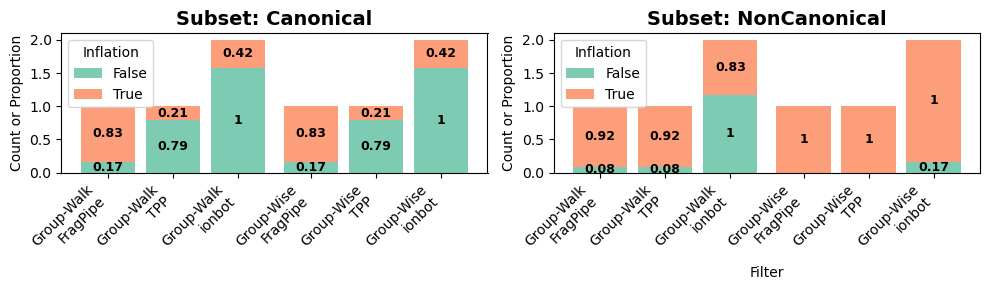

In [230]:
# --- Prepare data ---
res = res.rename(columns={'index': 'inflation', 0: 'count'}) if 'index' in res.columns else res
res['inflation'] = res['inflation'].astype(str)

# Optional: normalize to proportions
# res['count'] = res['count'] / res.groupby(['filter', 'pipeline', 'subsets'])['count'].transform('sum')

# --- Get unique subsets ---
subsets = res['subset'].unique()

# --- Create subplots ---
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(subsets),
    figsize=(10, 3),
    sharex=True
)

if len(subsets) == 1:
    axes = [axes]  # ensure iterable if only one subset

bar_centers = []  # x positions for individual bars
bar_labels = []   # corresponding "Filter\nPipeline" labels

for ax, subset in zip(axes, subsets):
    subset_df = res[res['subset'] == subset]

    pivot_df = (
        subset_df.pivot_table(
            index=['filter', 'pipeline'],
            columns='inflation',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        .reset_index()
    )

    filters = pivot_df['filter'].unique()
    pipelines = pivot_df['pipeline'].unique()
    inflations = [c for c in pivot_df.columns if c in ['True', 'False']]

    x = np.arange(len(filters))
    bar_width = 0.8 / len(pipelines)
    palette = sns.color_palette("Set2", n_colors=len(inflations))
    color_map = dict(zip(inflations, palette))

    for i, pipeline in enumerate(pipelines):
        df_sub = pivot_df[pivot_df['pipeline'] == pipeline]
        bar_spacing_factor = 1.2  # >1 increases gap, <1 decreases gap
        offset = (i - (len(pipelines) - 1) / 2) * bar_width * bar_spacing_factor
        bottom = np.zeros(len(filters))

        for infl in inflations:
            values = [df_sub.loc[df_sub['filter'] == f, infl].values[0] if len(df_sub.loc[df_sub['filter'] == f, infl].values) else 0 for f in filters]

            bars = ax.bar(
                x + offset,
                values,
                bar_width,
                bottom=bottom,
                color=color_map[infl],
                alpha=0.85,
                label=f"{infl}" if i == 0 else ""
            )

            for bar, value, btm in zip(bars, values, bottom):
                if value > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        btm + value / 2,
                        f"{value:.2f}" if value < 1 else f"{int(value)}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        color="black",
                        fontweight="bold"
                    )

            # save bar centers for x-axis labeling
            for xi in x + offset:
                if xi not in bar_centers:
                    bar_centers.append(xi)
                    bar_labels.append(f"{filters[list(x).index(xi - offset)]}\n{pipeline}")
    
            bottom += np.array(values)
            

    ax.set_title(f"Subset: {subset}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Count or Proportion")
    ax.set_xticks(bar_centers)
    ax.set_xticklabels(bar_labels, rotation=45, ha="right")
    ax.legend(title="Inflation")

plt.xlabel("Filter")
plt.tight_layout()
plt.show()


### Visualisation option 2: Gain/loss in IDs respective to global filter by group filter

#### Massages:
- Group filters substentualy reduce the number of false IDs among non-canonicals and open search (less IDs than with global filtering)
- Open search identified more non-canonicals even with stringent filter
- Ionbot FDR controll accids in identifications with group filtering, even with FDP-ranks

In [231]:
globinfl_df=[]
for (p,m,s), df in inflation_stats.sort_values(['dataset','sample']).groupby(['pipeline','mode','subset']):
    # normalise by N IDs of global filter (expected to be always bigger then group-FDR for non-canonical)
    global_filt = df[df['filter'] == 'Global']
    samples = global_filt['sample'].values.tolist()
    n = len(samples)
    for filt, other_filt in df[df['filter'] != 'Global'].groupby('filter'):
         #how much smaller or bigger set comparing to global filter
        global_inflation = ( other_filt.n_filter.values / global_filt.n_filter.values ) - 1
        global_inflation = [ 0 if _ == -1 else _ for _ in global_inflation ] # 0 IDs
        globinfl_df += [pd.DataFrame({'pipeline':[p]*n,'mode':[m]*n,'subset':[s]*n,'sample':samples,'filter':[filt]*n, 'global_inflation':global_inflation})]
        #print(s,filt, global_inflation)
        #print(other_filt['sample'],global_filt['sample']) #verify the paires of samples
globinfl_df=pd.concat(globinfl_df)

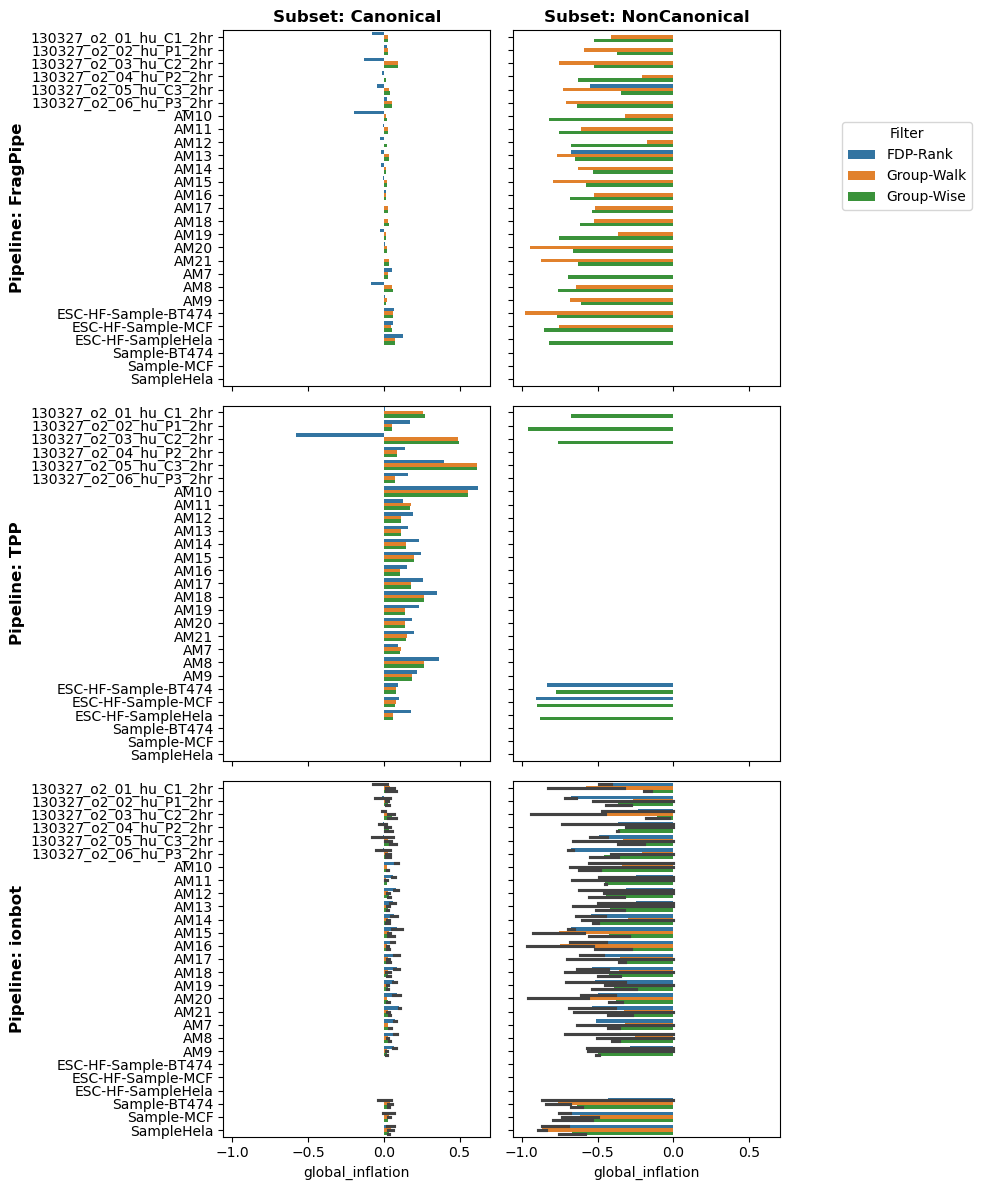

In [232]:
#ORDER so Closed search up

# --- Get unique pipelines and subsets ---
pipelines = globinfl_df['pipeline'].unique()
subsets = globinfl_df['subset'].unique()

n_rows = len(pipelines)
n_cols = len(subsets)

# --- Create subplots with shared x and y axes ---
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4*n_cols, 4*n_rows),
    sharex=True,
    sharey=True
)

# Ensure axes is always 2D array
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for i, pipeline in enumerate(pipelines):
    for j, subset in enumerate(subsets):
        ax = axes[i, j]
        df = globinfl_df[(globinfl_df['pipeline'] == pipeline) & (globinfl_df['subset'] == subset)]
        if not df.empty:
            sns.barplot(data=df, x='global_inflation', y='sample', hue='filter', ax=ax)
        if i == 0:
            ax.set_title(f'Subset: {subset}', fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'Pipeline: {pipeline}', fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel('')
        ax.legend_.remove()  # remove individual legends

# Put one shared legend on top/right
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Filter', bbox_to_anchor=(1.05, 0.9), loc='upper left')

plt.tight_layout()
plt.show()


/tmp/ipykernel_981921/3391258348.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_981921/3391258348.py:36: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  sns.barplot(
/tmp/ipykernel_981921/3391258348.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_981921/3391258348.py:36: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  sns.barplot(
/tmp/ipykernel_981921/3391258348.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_981921/3391258348.py:36: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  sns.b

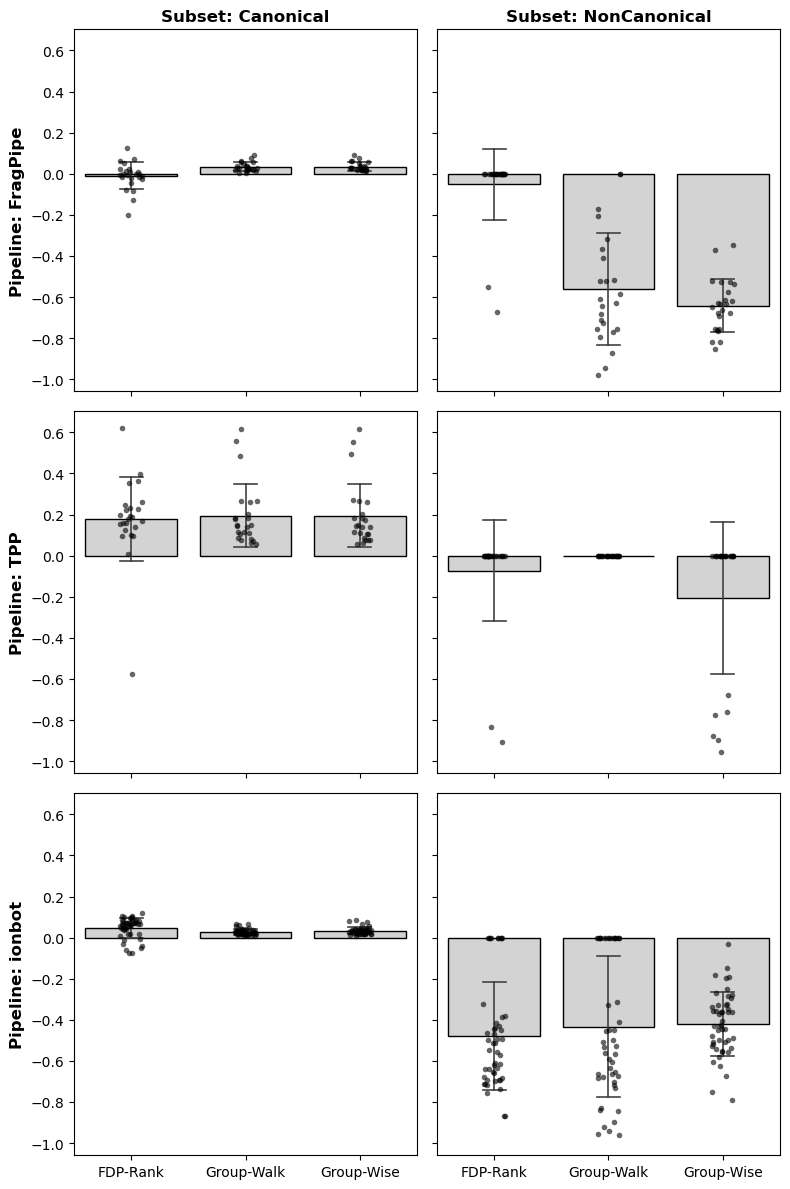

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Get unique pipelines and subsets ---
pipelines = globinfl_df['pipeline'].unique()
subsets = globinfl_df['subset'].unique()

n_rows = len(pipelines)
n_cols = len(subsets)

# --- Create subplots with shared x and y axes ---
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=True
)

# Ensure axes is always 2D array
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

# --- Define filter order (Closed first) ---
filter_order = sorted(globinfl_df['filter'].unique(), key=lambda x: (x != 'Closed', x))

for i, pipeline in enumerate(pipelines):
    for j, subset in enumerate(subsets):
        ax = axes[i, j]
        df = globinfl_df[(globinfl_df['pipeline'] == pipeline) & (globinfl_df['subset'] == subset)]
        if not df.empty:
            # Barplot with mean and std
            sns.barplot(
                data=df,
                x='filter',
                y='global_inflation',
                order=filter_order,
                ax=ax,
                ci='sd',          # show standard deviation
                capsize=0.2,      # add caps to error bars
                errwidth=1.2,
                color='lightgray',
                edgecolor='black'
            )

            # Overlay individual data points (jittered)
            sns.stripplot(
                data=df,
                x='filter',
                y='global_inflation',
                order=filter_order,
                ax=ax,
                color='black',
                alpha=0.6,
                size=4,
                jitter=True
            )

        # Titles and labels
        if i == 0:
            ax.set_title(f'Subset: {subset}', fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'Pipeline: {pipeline}', fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')
        ax.legend_.remove() if ax.get_legend() else None

# Shared legend (if needed)
handles, labels = ax.get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, title='Filter', bbox_to_anchor=(1.05, 0.9), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
#does FDP of group-wis/walk rescued samples (low ID but not 0 compared to FDP) - correcpond to samples with FDP ~1% in entrapment?

### Visualisation option 3: absolut number of IDs per smaple and group filter

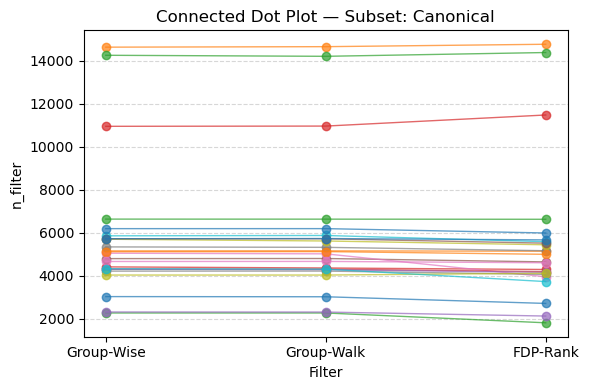

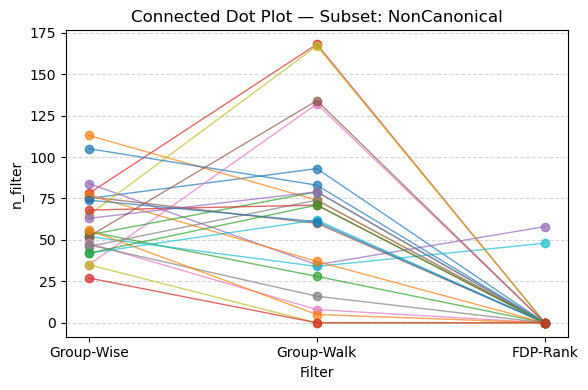

In [119]:
desired_order = ['Group-Wise', 'Group-Walk', 'FDP-Rank']

for subset, b in inflation_stats[inflation_stats.pipeline=='FragPipe'].groupby('subset'):
    # Pivot to get filters as columns
    b_pivot = b.pivot(index="sample", columns="filter", values="n_filter")
    # Reorder columns
    b_pivot = b_pivot.reindex(columns=desired_order)

    plt.figure(figsize=(6, 4))
    
    # Plot each sample as a line connecting dots
    for sample in b_pivot.index:
        plt.plot(desired_order, b_pivot.loc[sample], marker='o', linewidth=1, alpha=0.7)
    
    # Style
    plt.title(f"Connected Dot Plot — Subset: {subset}")
    plt.xlabel("Filter")
    plt.ylabel("n_filter")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


### 1% FDR rank non-entrapment = 1% FDR rank entrapment ?

In [253]:
def compare_filters_ranks(run, folders, filt_q_names, pipeline, mode, qval_score, qval_thresh):
    stats = {k: [] for k in ['run','pipeline', 'mode', 'dataset', 'sample', 'database', 'subset', 'filter', 'max_rank_fdr']}    
    for dataset_name in PXDs:
        for search in SEARCHES:
            if search != 'openprot': 
                continue
            for file in folders[search][dataset_name]:
                #print(file)
                data = pd.read_csv(file)#.query("isTarget")  # filter out decoys directly
                data = data[data.isTarget==True]
                
                if 'group-walk-output-peptide' in str(file):
                    sample = file.split('/')[-2].replace('-closed','').replace(f'-{search}','')
                else:
                    sample = (file.split('/')[-1]
                              .split('.')[0]
                              .replace('groupwalk_output_', '')
                              .replace(f'_{search}_PeptideProphet', '')
                              .replace('_pep', ''))
                
                for subset, df in data.groupby('FDRGroup'):
                    if subset == 'Contam':
                        continue
                    for filt, q_val in filt_q_names.items():
                        max_rank_fdr = df[df[q_val]<=qval_thresh]['subset_rank'].max()
                        stats['run'] += [run]
                        stats['pipeline'] += [pipeline]
                        stats['mode'] += [mode]
                        stats['dataset'] += [dataset_name]
                        stats['sample'] += [sample]
                        stats['database'] += [search]
                        stats['subset'] += [subset]
                        stats['filter'] += [filt]
                        stats['max_rank_fdr'] += [max_rank_fdr]
    return pd.DataFrame(stats)

In [254]:
run = 'NonEntr'
qval_thresh = 0.01
pipeline_mode_folders = [('TPP','Closed', folders_tpp),('FragPipe','Open', folders_fragpipe),
                        ('ionbot','Closed',folders_ionbot_closed),('ionbot','Open',folders_ionbot_open)]

# TPP & FragPipe
filt_q_names={'Group-Wise':'custom_q','Group-Walk':'group_q_prob','Global':'global_q'}
qval_score='peptideprophet_probability'

# Get max ranks of 1% FDR
fdrranks_stats = []
for pipeline, mode, folders in pipeline_mode_folders[:2]:
    print(pipeline)
    fdrranks_stats+= [ compare_filters_ranks(run, folders, filt_q_names, pipeline, mode, qval_score, qval_thresh) ]

# ionbot
filt_q_names={'Group-Wise':'custom_q','Group-Walk':'group_qval','Global':'q.value'}
qval_score='psm_score'
for pipeline, mode, folders in pipeline_mode_folders[2:]:
    print(pipeline)
    fdrranks_stats+= [ compare_filters_ranks(run, folders, filt_q_names, pipeline, mode, qval_score, qval_thresh) ]

fdrranks_stats = pd.concat(fdrranks_stats)
fdrranks_stats['max_rank_fdr'] = fdrranks_stats['max_rank_fdr'].fillna(0)

# correct sample
fdrranks_stats['sample'] = fdrranks_stats['sample'].str.lower().str.replace('esc-hf-','')

TPP
FragPipe
ionbot
ionbot


In [281]:
# read entrapment ranks
root = '/project/def-marie87/vvshazia/pride_reanalysis/Ionbot_FDP'
entr_res_classic = f'{root}/IonbotData_tpp_fragpipe_ranks_groupwalk_151025/results/peptide_level'
entr_res_ionbot = f'{root}/IonbotData_ionbot_ranks_181025/results/peptide_level'
# read by-sample statistics
subsets_fdp_bythresh = pd.concat([pd.read_csv(f'{_}/all_bysample_stats_subsets.csv') for _ in [entr_res_classic, entr_res_ionbot] ])
# modify search type
subsets_fdp_bythresh['pipeline'] = subsets_fdp_bythresh['search_type'].map({'TPP_PTM':'TPP','FragPipe_PTM':'FragPipe','OpenSearch':'ionbot','ClosedSearch':'ionbot'})
subsets_fdp_bythresh['mode'] = subsets_fdp_bythresh['search_type'].map({'TPP_PTM':'Closed','FragPipe_PTM':'Open','OpenSearch':'Open','ClosedSearch':'Closed'})
# correct sample names
subsets_fdp_bythresh['sample'] = subsets_fdp_bythresh['sample'].str.split('_fdp').str[0].str.replace('esc-hf-','').str.replace('canonical_|noncanonical_', '', regex=True).str.lower()
#correct subset names
subsets_fdp_bythresh['subset'] = subsets_fdp_bythresh['subset'].map({'canonical':'Canonical','noncanonical':'NonCanonical'})
# samples with 0 IDs
subsets_fdp_bythresh['zero_ids_fdr'] = subsets_fdp_bythresh['Total target discoveries 1% FDR'] == 0
subsets_fdp_bythresh['zero_ids_fdp'] = subsets_fdp_bythresh['Total target discoveries 1% paired FDP'] == 0
# rename approach
subsets_fdp_bythresh['approach'] = subsets_fdp_bythresh['approach'].map({'classic':'Global','groupwise':'Group-Wise','groupwalk':'Group-Walk'})
# correct database
subsets_fdp_bythresh['database'] = 'openprot'

In [282]:
# format to NonEntr table
fdrranks_entr = subsets_fdp_bythresh[['Max rank 1% FDR','sample', 'subset', 'dataset',
       'database', 'approach', 'pipeline', 'mode',]]
fdrranks_entr['run'] = 'Entr'
fdrranks_entr['Max rank 1% FDR'] = fdrranks_entr['Max rank 1% FDR'].fillna(0)
fdrranks_entr = fdrranks_entr[['run','pipeline','mode', 'dataset', 'sample', 'database', 'subset', 'approach', 'Max rank 1% FDR']]
fdrranks_entr.columns = fdrranks_stats.columns

#merge
data = pd.concat([fdrranks_stats,fdrranks_entr])

/tmp/ipykernel_981921/4215317156.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdrranks_entr['run'] = 'Entr'
/tmp/ipykernel_981921/4215317156.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdrranks_entr['Max rank 1% FDR'] = fdrranks_entr['Max rank 1% FDR'].fillna(0)


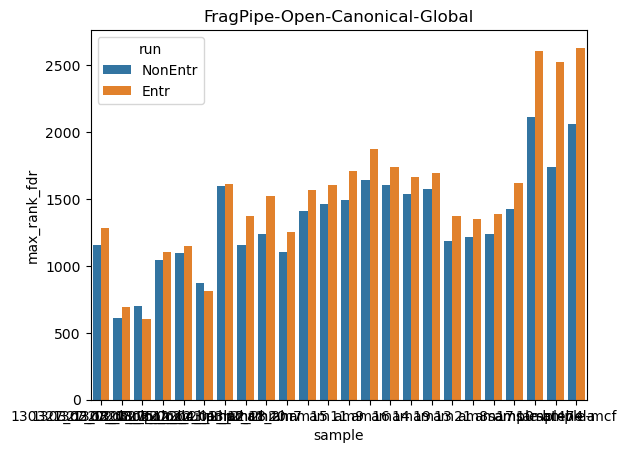

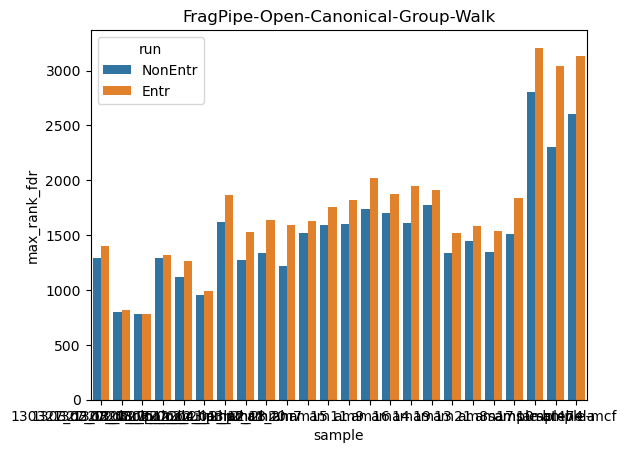

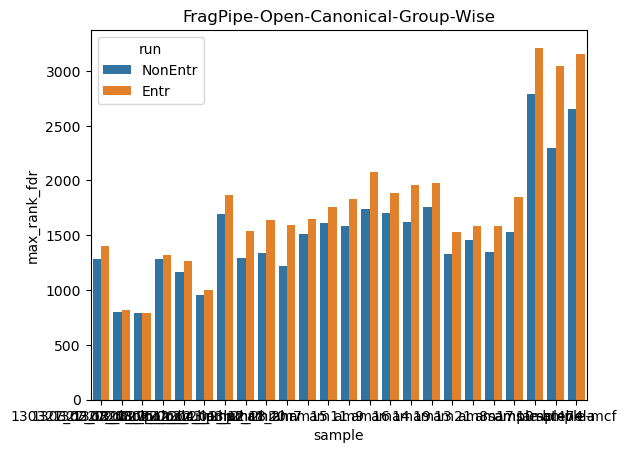

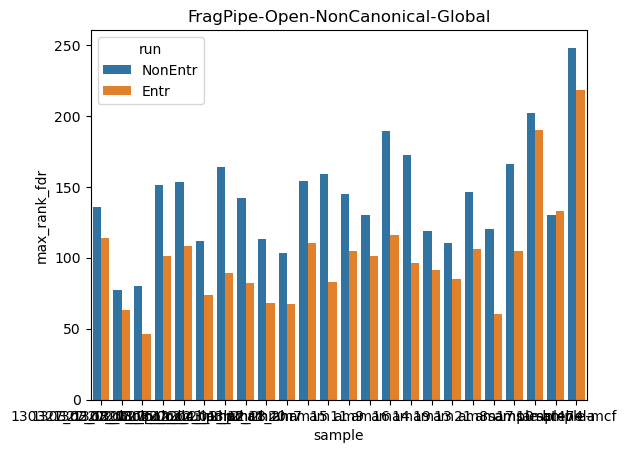

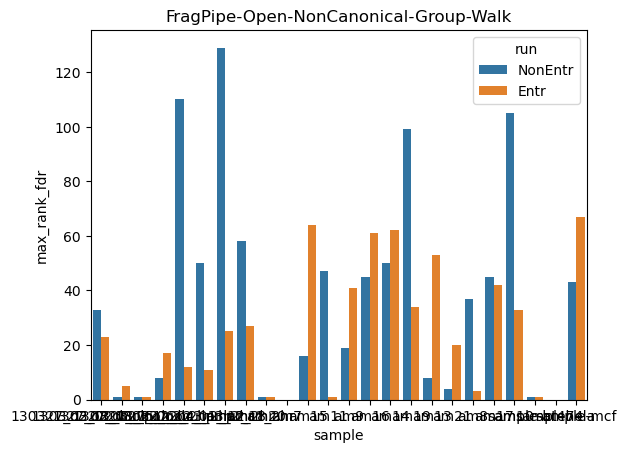

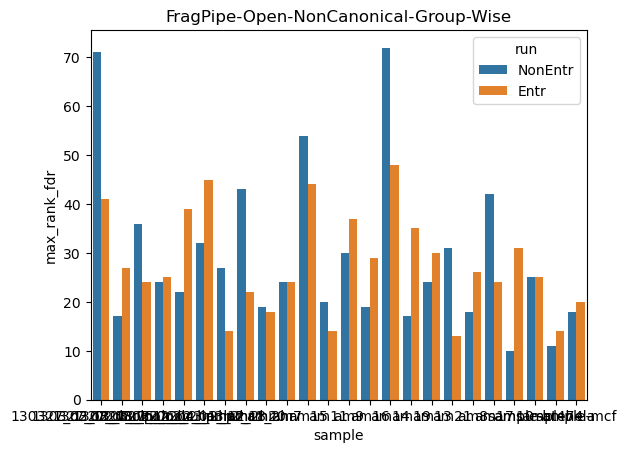

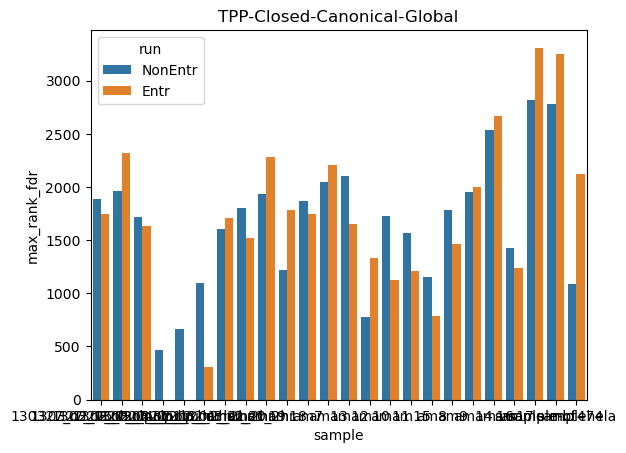

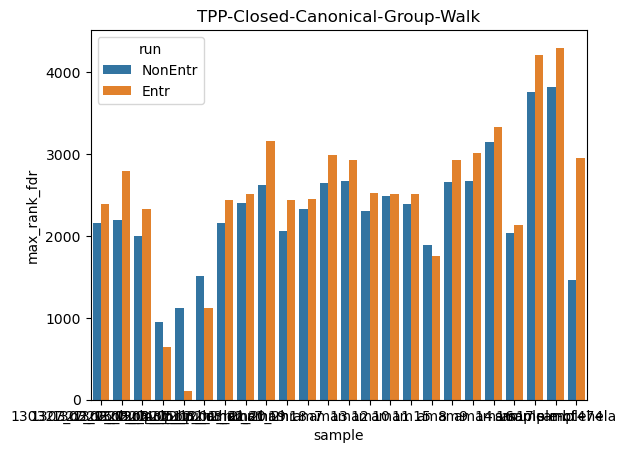

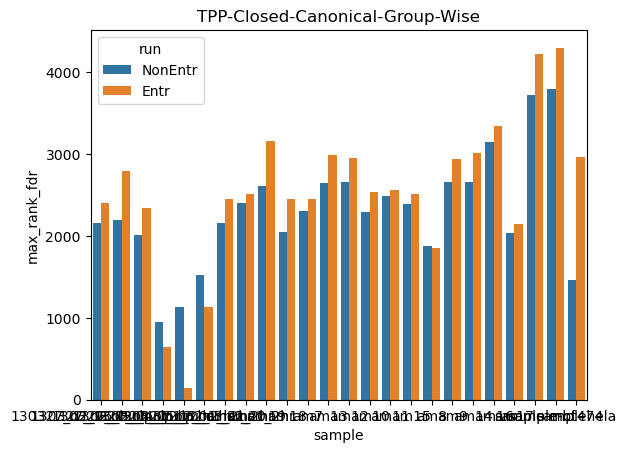

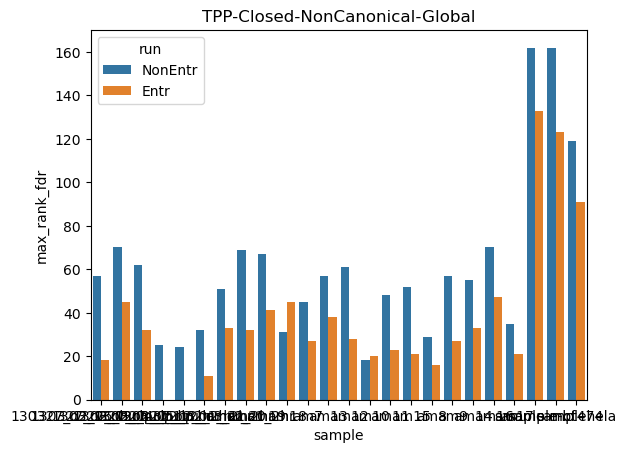

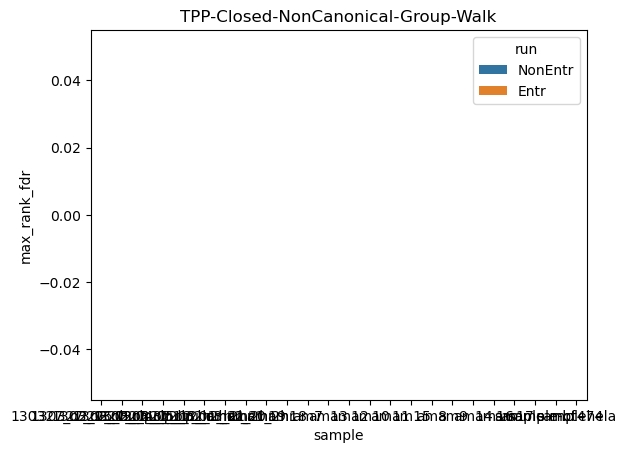

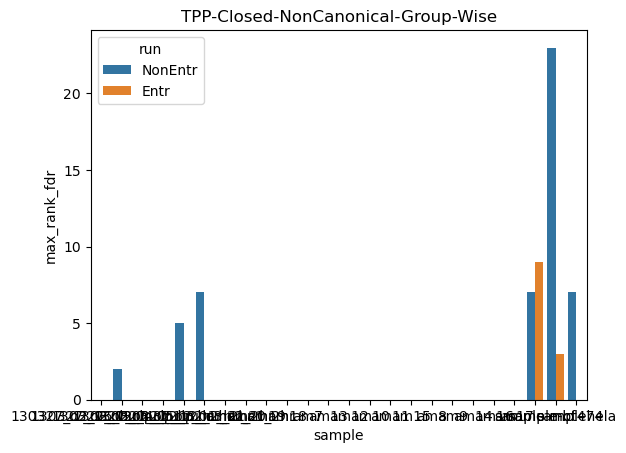

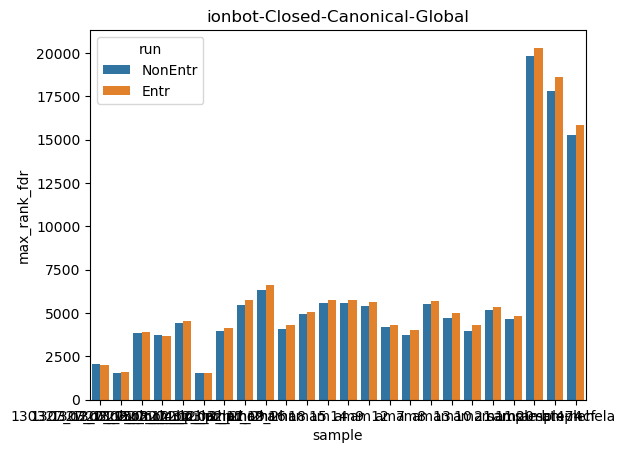

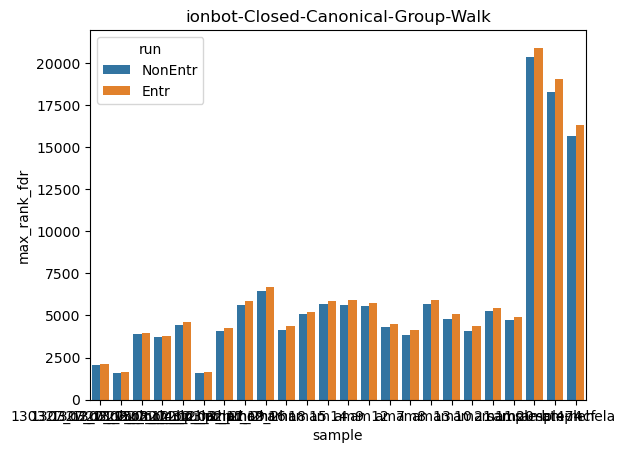

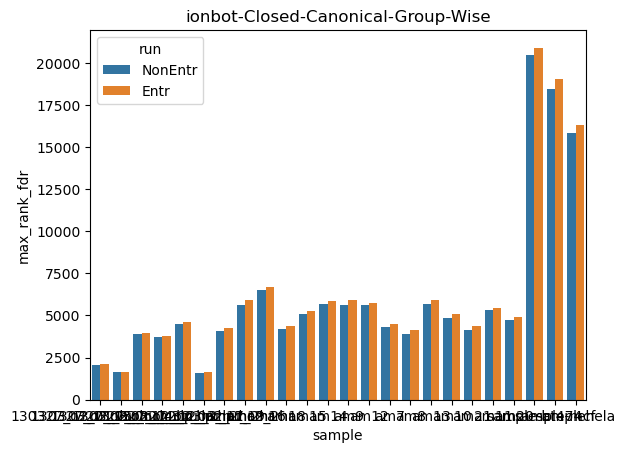

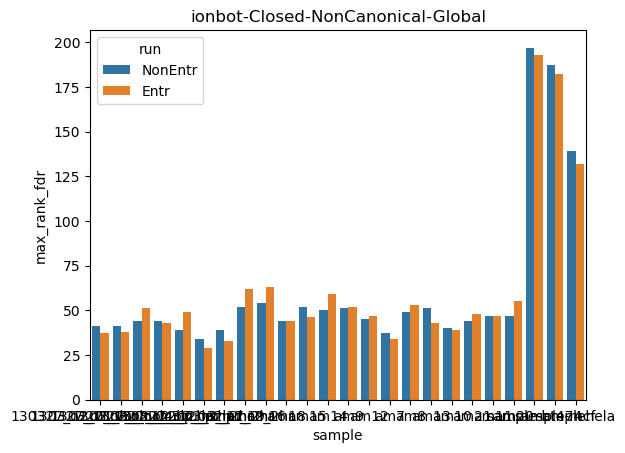

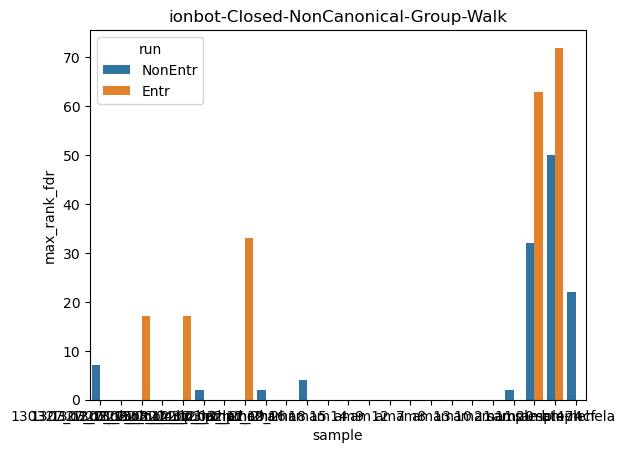

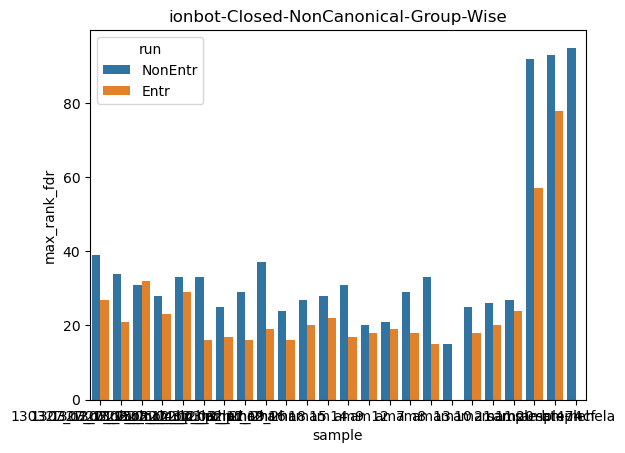

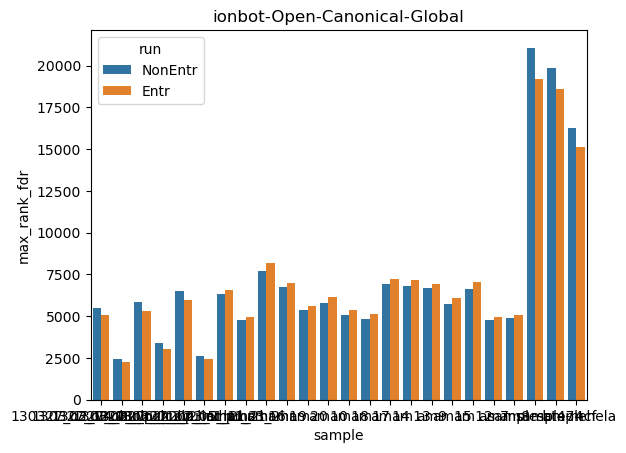

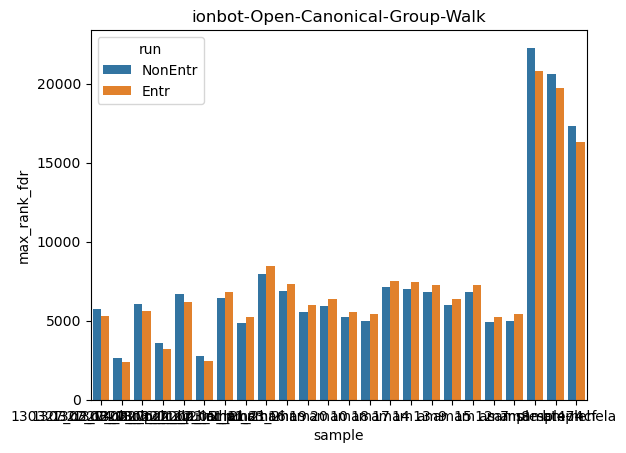

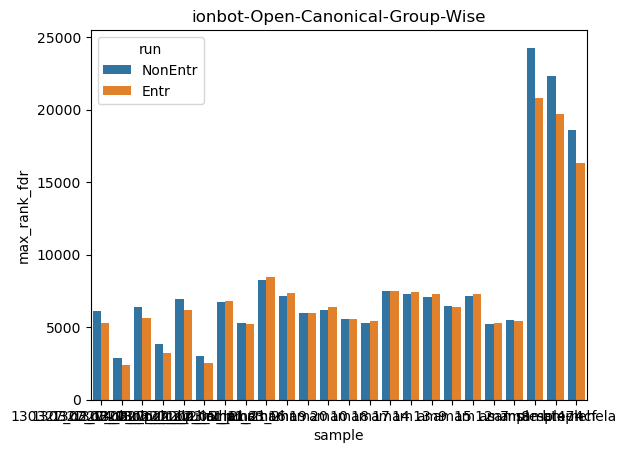

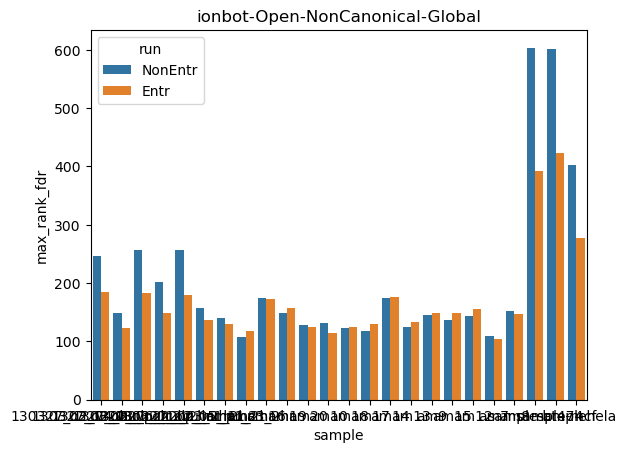

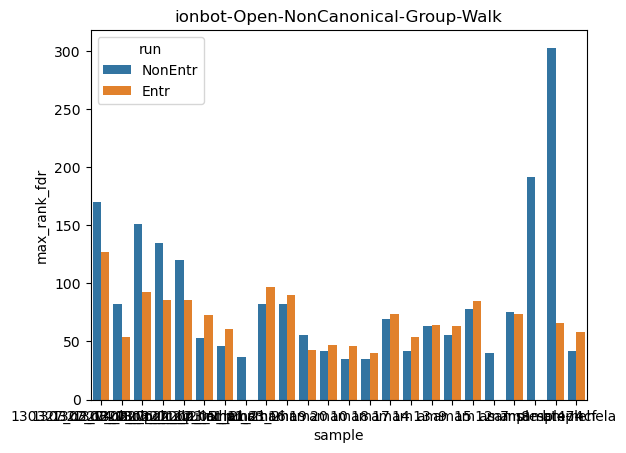

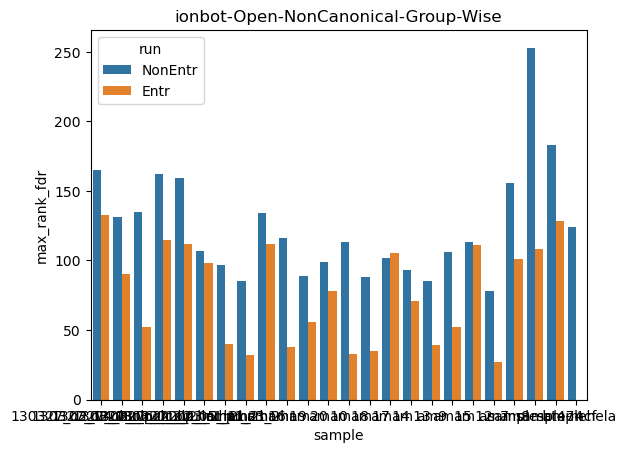

In [283]:
# Conclusions from barplot:
# The difference is small
# Canonical - Entr max ranks are slightly bigger
# Non-canonical - NonEntr max ranks are sligntly bigger
# How the N of IDs in NonEntr change comparing 1% FDR NonEntr and max rank 1% FDR Entr?
# This way we can prognose what is our error (deviation) of 1% FDP threshold put in max rank Entr from expected max-rank for NonEntr
# We could do this for different FDR/FDP thresholds and see if correlation of error is linear to threshold
# Vis. 1: Dotplot by subset and pipeline - max-rank-1%-FDR-Entr VS max-rank-1%-FDR-NonEntr
# Vis. 2: (1) Select max-rank Entr and NonEntr for FDR 0.1% - 10% with step 0.1% 
# (2) Normalise max-rank-1%-FDR-Entr/max-rank-1%-FDR-NonEntr for each step, pipeline and subset
# (3) Dotplot step VS Normalised ranks by pipeline and subset
for (p,m,s,f), df in data.groupby(['pipeline','mode','subset','filter']):
    sns.barplot(data=df, x='sample',y='max_rank_fdr', hue='run')
    plt.title('-'.join((p,m,s,f)))
    plt.show()

In [ ]:
# Vis. 1
# Do only on Global

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [ ]:
# classical pipelines

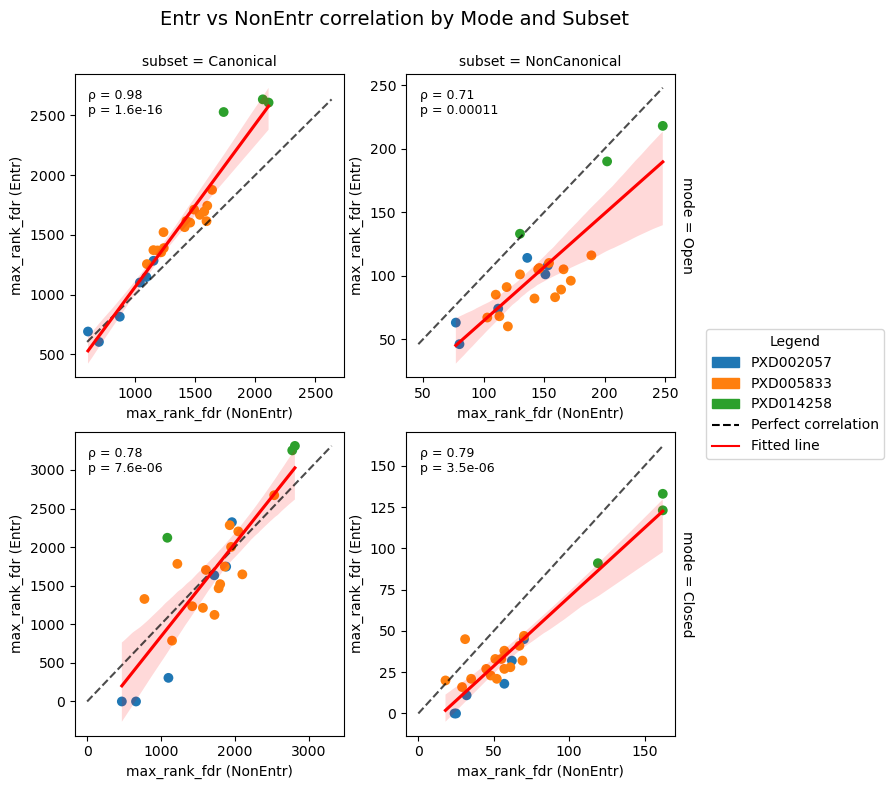

In [294]:
# Filter and merge Entr vs NonEntr
df_global = data[(data['filter'] == 'Global')&(data['pipeline'].isin(['TPP','FragPipe']))]
entr = df_global[df_global['run'] == 'Entr']
nonentr = df_global[df_global['run'] == 'NonEntr']

merged = entr.merge(
    nonentr,
    how='outer',
    suffixes=('_entr', '_nonentr'),
    on=['pipeline', 'mode', 'dataset', 'sample', 'database', 'subset', 'filter']
)

# Base palette for datasets
datasets = merged['dataset'].unique()
palette = sns.color_palette('tab10', len(datasets))
color_dict = dict(zip(datasets, palette))

# Function to draw each subplot
def corr_scatter(data, color, **kwargs):
    ax = plt.gca()

    # Scatter plot colored by dataset
    sns.scatterplot(
        data=data,
        x='max_rank_fdr_nonentr',
        y='max_rank_fdr_entr',
        hue='dataset',
        palette=color_dict,
        s=50,
        edgecolor='none',
        ax=ax,
        legend=False
    )

    # Perfect correlation line (y = x)
    lims = [
        np.nanmin([data['max_rank_fdr_nonentr'], data['max_rank_fdr_entr']]),
        np.nanmax([data['max_rank_fdr_nonentr'], data['max_rank_fdr_entr']])
    ]
    ax.plot(lims, lims, 'k--', alpha=0.7)

    # Fitted line
    sns.regplot(
        data=data,
        x='max_rank_fdr_nonentr',
        y='max_rank_fdr_entr',
        scatter=False,
        color='red',
        ax=ax
    )

    # Spearman correlation coefficient
    mask = data[['max_rank_fdr_nonentr', 'max_rank_fdr_entr']].dropna()
    if not mask.empty:
        rho, pval = spearmanr(mask['max_rank_fdr_nonentr'], mask['max_rank_fdr_entr'])
        ax.text(
            0.05, 0.95,
            f"ρ = {rho:.2f}\np = {pval:.2g}",
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    ax.set_xlabel("max_rank_fdr (NonEntr)")
    ax.set_ylabel("max_rank_fdr (Entr)")

# Facet grid: independent axes
g = sns.FacetGrid(
    merged,
    row='mode',
    col='subset',
    margin_titles=True,
    despine=False,
    height=4,
    aspect=1,
    sharex=False,
    sharey=False
)
g.map_dataframe(corr_scatter)

# --- Custom combined legend ---
# Dataset color markers
dataset_handles = [
    Patch(color=color_dict[d], label=d) for d in datasets
]

# Line annotations
line_handles = [
    Line2D([0], [0], color='k', linestyle='--', label='Perfect correlation'),
    Line2D([0], [0], color='red', linestyle='-', label='Fitted line')
]

# Combine all legend elements
handles = dataset_handles + line_handles
labels = [h.get_label() for h in handles]

# Place legend outside
g.fig.legend(
    handles=handles,
    labels=labels,
    title='Legend',
    loc='center right',
    bbox_to_anchor=(1.12, 0.5),
    frameon=True
)

plt.subplots_adjust(top=0.9, right=0.85)
g.fig.suptitle("Entr vs NonEntr correlation by Mode and Subset", fontsize=14)
plt.show()


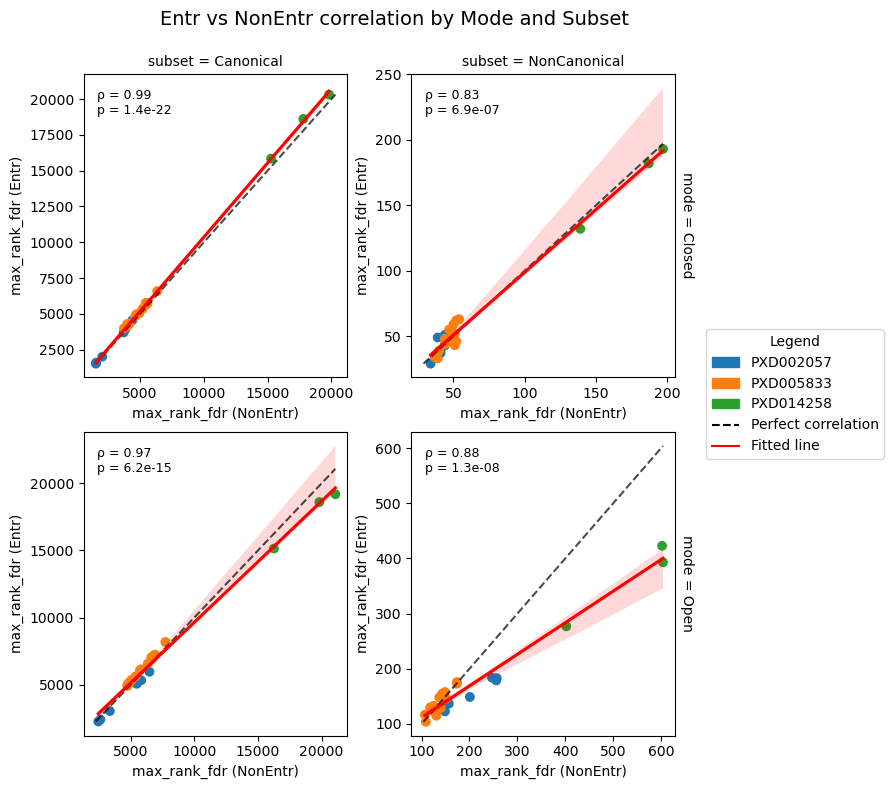

In [296]:
# Filter and merge Entr vs NonEntr
df_global = data[(data['filter'] == 'Global')&(data['pipeline'] == 'ionbot')]
entr = df_global[df_global['run'] == 'Entr']
nonentr = df_global[df_global['run'] == 'NonEntr']

merged = entr.merge(
    nonentr,
    how='outer',
    suffixes=('_entr', '_nonentr'),
    on=['pipeline', 'mode', 'dataset', 'sample', 'database', 'subset', 'filter']
)

# Base palette for datasets
datasets = merged['dataset'].unique()
palette = sns.color_palette('tab10', len(datasets))
color_dict = dict(zip(datasets, palette))

# Function to draw each subplot
def corr_scatter(data, color, **kwargs):
    ax = plt.gca()

    # Scatter plot colored by dataset
    sns.scatterplot(
        data=data,
        x='max_rank_fdr_nonentr',
        y='max_rank_fdr_entr',
        hue='dataset',
        palette=color_dict,
        s=50,
        edgecolor='none',
        ax=ax,
        legend=False
    )

    # Perfect correlation line (y = x)
    lims = [
        np.nanmin([data['max_rank_fdr_nonentr'], data['max_rank_fdr_entr']]),
        np.nanmax([data['max_rank_fdr_nonentr'], data['max_rank_fdr_entr']])
    ]
    ax.plot(lims, lims, 'k--', alpha=0.7)

    # Fitted line
    sns.regplot(
        data=data,
        x='max_rank_fdr_nonentr',
        y='max_rank_fdr_entr',
        scatter=False,
        color='red',
        ax=ax
    )

    # Spearman correlation coefficient
    mask = data[['max_rank_fdr_nonentr', 'max_rank_fdr_entr']].dropna()
    if not mask.empty:
        rho, pval = spearmanr(mask['max_rank_fdr_nonentr'], mask['max_rank_fdr_entr'])
        ax.text(
            0.05, 0.95,
            f"ρ = {rho:.2f}\np = {pval:.2g}",
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    ax.set_xlabel("max_rank_fdr (NonEntr)")
    ax.set_ylabel("max_rank_fdr (Entr)")

# Facet grid: independent axes
g = sns.FacetGrid(
    merged,
    row='mode',
    col='subset',
    margin_titles=True,
    despine=False,
    height=4,
    aspect=1,
    sharex=False,
    sharey=False
)
g.map_dataframe(corr_scatter)

# --- Custom combined legend ---
# Dataset color markers
dataset_handles = [
    Patch(color=color_dict[d], label=d) for d in datasets
]

# Line annotations
line_handles = [
    Line2D([0], [0], color='k', linestyle='--', label='Perfect correlation'),
    Line2D([0], [0], color='red', linestyle='-', label='Fitted line')
]

# Combine all legend elements
handles = dataset_handles + line_handles
labels = [h.get_label() for h in handles]

# Place legend outside
g.fig.legend(
    handles=handles,
    labels=labels,
    title='Legend',
    loc='center right',
    bbox_to_anchor=(1.12, 0.5),
    frameon=True
)

plt.subplots_adjust(top=0.9, right=0.85)
g.fig.suptitle("Entr vs NonEntr correlation by Mode and Subset", fontsize=14)
plt.show()
